# Week 3 · Notebook 2 — Intensification, Diversification and Reactive Tabu Search

**Goals**
- Extend short-term (recency) memory with **long-term memory**: residence frequencies used as diversification
  penalties, and an **elite set** used for intensification by **path relinking** (Glover & Laguna, 1997).
- Implement **robust tabu search** (Taillard, 1991): randomised tenure, weak tabu-activation rule and long-term
  aspiration.
- Implement **reactive tabu search** (Battiti & Tecchiolli, 1994): the tenure adapts online by detecting
  repeated solutions through hashing (Zobrist hashing, validated against exact keys).
- Compare all variants on random QAP instances at an equal evaluation budget over several seeds.
- Implement **strategic oscillation** around the feasibility boundary of the 0/1 knapsack problem and validate it
  against the exact dynamic programme `knapsack_dp`.

**Prerequisites:** Notebook 1 (tabu search, QAP swap deltas, tenure, aspiration).

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from utils import set_style, savefig, check_close, check_true
set_style()
rng = np.random.default_rng(0)
import time
from utils import random_qap, qap_cost, random_knapsack, knapsack_dp, PALETTE

## 1. Short-term vs long-term memory

Glover's framework distinguishes four dimensions of memory (Glover & Laguna 1997, ch. 3–4):

| Memory | Records | Typical use |
|---|---|---|
| **Recency** (short-term) | iteration at which an attribute last changed | tabu status (Notebook 1) |
| **Frequency** (long-term) | how often an attribute was present (*residence*) or changed (*transition*) | diversification penalties/incentives |
| **Quality** | elite solutions and their shared attributes | intensification, path relinking |
| **Influence** | how much a choice changed the search | candidate-list design |

**Intensification** concentrates effort in regions that contain good solutions (restart from elites, fix attributes
common to elites, relink elites). **Diversification** drives the search into regions it has not explored
(penalise frequent attributes, restart with rarely used attributes). A good TS alternates the two; the tabu list
alone only prevents *immediate* reversal.

**Frequency-based diversification (residence).** Let $h_{i\ell}(k)$ be the number of iterations, up to $k$, in
which facility $i$ sat at location $\ell$. For a swap $(r,s)$ that is **not improving** ($\Delta \ge 0$) the search
ranks moves by the penalised value

$$
\tilde\Delta(r,s) = \Delta(r,s) + \lambda \, \bar\delta \, \frac{h_{r \pi_s}(k) + h_{s \pi_r}(k)}{k},
$$

where $\bar\delta$ is the mean $\vert\Delta\vert$ of the initial neighbourhood (to make $\lambda$ scale-free).
Improving moves are never penalised, so the rule only acts once the search has to climb.

## 2. QAP machinery (from Notebook 1)

We reuse the swap delta matrix $\Delta_{rs} = 2 (M_{rs} + M_{sr} - M_{rr} - M_{ss} + 2 F_{rs} d_{rs})$ with
$M = F [D_{\pi_i \pi_j}]$ and Taillard's $O(n^2)$ update, re-validated here against direct recomputation.

In [2]:
def qap_delta_matrix(p, F, D):
    Dp = D[np.ix_(p, p)]
    M = F @ Dp
    dg = np.diag(M)
    Delta = 2.0 * (M + M.T - dg[:, None] - dg[None, :] + 2.0 * F * Dp)
    np.fill_diagonal(Delta, 0.0)
    return Delta


def qap_update_after_swap(Delta, q, r, s, F, D):
    """Taillard's O(n^2) update of the delta matrix; q is the permutation after swap (r, s)."""
    a = F[r] - F[s]
    b = D[q[s], q] - D[q[r], q]
    new = Delta + 2.0 * np.subtract.outer(a, a) * np.subtract.outer(b, b)
    Dq = D[np.ix_(q, q)]
    diagM = np.sum(F * Dq, axis=0)
    for i in (r, s):
        row = 2.0 * (F[:, i] @ Dq + Dq[:, i] @ F - diagM[i] - diagM + 2.0 * F[i] * Dq[i])
        new[i, :] = row
        new[:, i] = row
    np.fill_diagonal(new, 0.0)
    return new


def qap_delta(p, r, s, F, D):
    dF = F[:, r] - F[:, s]
    dD = D[p, p[s]] - D[p, p[r]]
    return 2.0 * (dF @ dD + 2.0 * F[r, s] * D[p[r], p[s]])


Ft, Dt = random_qap(12, rng)
p = rng.permutation(12)
Delta = qap_delta_matrix(p, Ft, Dt)
for _ in range(100):
    r, s = rng.choice(12, 2, replace=False)
    q = p.copy(); q[[r, s]] = q[[s, r]]
    Delta = qap_update_after_swap(Delta, q, r, s, Ft, Dt)
    p = q
brute = np.array([[0.0 if r == s else qap_cost(np.where(np.arange(12) == r, p[s], np.where(np.arange(12) == s, p[r], p)),
                                                  Ft, Dt) - qap_cost(p, Ft, Dt) for s in range(12)] for r in range(12)])
check_close(np.abs(Delta - brute).max(), 0.0, "incremental delta matrix after 100 moves vs recomputation", atol=1e-7)

[PASS] incremental delta matrix after 100 moves vs recomputation: got 0.0, expected 0.0


## 3. Zobrist hashing of permutations

Reactive TS needs to recognise a *repeated solution* in $O(1)$. Zobrist (1970) hashing assigns a random 64-bit
key $z_{i\ell}$ to every (facility, location) pair and hashes $\pi$ as $H(\pi) = \bigoplus_i z_{i \pi_i}$ (bitwise XOR).
A swap $(r,s)$ changes only two terms, so the hash updates in $O(1)$:

$$
H(\pi') = H(\pi) \oplus z_{r\pi_r} \oplus z_{s\pi_s} \oplus z_{r\pi_s} \oplus z_{s\pi_r}.
$$

For $m$ stored solutions the probability of any collision is at most $m^2 / 2^{65}$ (birthday bound), negligible
here; we nevertheless verify it against exact byte keys.

In [3]:
def zobrist_table(n, rng):
    """Independent uniform 64-bit keys z[i, l] for every (facility, location) pair."""
    return rng.integers(0, 2**64, size=(n, n), dtype=np.uint64, endpoint=False)

def zobrist_full(p, Z):
    return int(np.bitwise_xor.reduce(Z[np.arange(len(p)), p]))

def zobrist_swap(h, p, r, s, Z):
    """Hash after swapping r, s given hash h of p (p is the permutation *before* the swap)."""
    return h ^ int(Z[r, p[r]]) ^ int(Z[s, p[s]]) ^ int(Z[r, p[s]]) ^ int(Z[s, p[r]])

Z = zobrist_table(30, rng)
p = rng.permutation(30); h = zobrist_full(p, Z)
exact, hashed, ok = set(), set(), True
for _ in range(20_000):
    r, s = rng.choice(30, 2, replace=False)
    h = zobrist_swap(h, p, r, s, Z)
    p[[r, s]] = p[[s, r]]
    ok &= h == zobrist_full(p, Z)
    exact.add(p.tobytes()); hashed.add(h)
check_true(ok, "incremental Zobrist hash equals full recomputation along 20,000 random swaps")
check_true(len(exact) == len(hashed), f"no collisions: {len(hashed)} distinct hashes for {len(exact)} distinct permutations")

[PASS] incremental Zobrist hash equals full recomputation along 20,000 random swaps
[PASS] no collisions: 19963 distinct hashes for 19963 distinct permutations


## 4. One tabu-search engine, four memory strategies

**Robust tabu search (Taillard 1991).** Weak tabu-activation rule (swap tabu only if *both* facilities would return
to recently left locations), tenure drawn uniformly from $[0.9n, 1.1n]$ and re-drawn every $2 \cdot 1.1 n$
iterations, aspiration by objective, plus a **long-term aspiration**: a move that places a facility on a location
it has not occupied for more than $t_{asp}$ iterations is taken at once (the best such move if there are several;
a diversification device). As in Taillard's reference code, every attribute is treated as "last used at
iteration 0", so this criterion cannot fire during the first $t_{asp}$ iterations — otherwise *every* never-used
facility–location pair would count as "unused for a long time" and the first few hundred moves would be forced
regardless of cost. The only randomness is in the tenure, yet it breaks the deterministic periodicity of
fixed-tenure TS (Notebook 1, §4).

**Reactive tabu search (Battiti & Tecchiolli 1994).**

```text
T <- 1 ; hash table H of visited solutions -> (last visit time, count)
each iteration k, after the move to x:
    if x in H:                                   # repetition detected
        R <- k - H[x].time ; H[x].count += 1
        if R < 2(n-1): avg <- 0.1 R + 0.9 avg ; T <- min(1.1 T, T_max) ; t_change <- k
        if H[x].count > REP: chaotic += 1
        if chaotic > CHAOS: chaotic <- 0 ; escape by 1 + (1 + u) avg/2 random moves, u ~ U(0,1)
    else: insert x
    if k - t_change > avg: T <- max(0.9 T, 1) ; t_change <- k
```

The constants $1.1$, $0.9$, `REP = CHAOS = 3` are those proposed by Battiti & Tecchiolli. The *prohibition period*
$T$ therefore grows exactly when the trajectory revisits solutions and shrinks when it has not for a while: the
tenure is **learned** rather than tuned.

All variants count one evaluation per neighbour examined ($n(n-1)/2$ per iteration) and one per random escape
move, and stop at the same budget.

In [4]:
def ts_qap(F, D, max_evals, rng, rule="either", tenure=10, robust=False, t_asp=None, freq_lambda=0.0,
           reactive=False, p0=None, record=False):
    """General tabu search for symmetric QAP (swap moves, full neighbourhood, incremental deltas)."""
    n = len(F)
    p = rng.permutation(n) if p0 is None else np.array(p0)
    cost = qap_cost(p, F, D)
    best, best_p = cost, p.copy()
    Delta = qap_delta_matrix(p, F, D)
    iu, ju = np.triu_indices(n, 1)
    tabu_until = np.full((n, n), -10**9, dtype=np.int64)
    tabu_until[np.arange(n), p] = 0                       # "left" at time 0 = currently occupied
    last_left = np.zeros((n, n), dtype=np.int64)          # long-term aspiration: every pair "used" at time 0
    freq = np.zeros((n, n))
    dbar = np.mean(np.abs(Delta[iu, ju]))
    evals, k = 0, 0
    # robust tenure
    t_hi = int(np.ceil(1.1 * n)); t_lo = int(np.floor(0.9 * n))
    t_cur = tenure
    # reactive state
    T, avg, t_change, chaotic = 1.0, 1.0, 0, 0
    Zt = zobrist_table(n, rng) if reactive else None
    h = zobrist_full(p, Zt) if reactive else 0
    H = {}
    rec = dict(cost=[], best=[], tenure=[], rep_iters=[], escapes=[])
    step = len(iu)
    while evals + step <= max_evals:
        k += 1
        evals += step
        d = Delta[iu, ju]
        if robust and (k - 1) % (2 * t_hi) == 0:
            t_cur = int(rng.integers(t_lo, t_hi + 1))
        if reactive:
            t_cur = int(np.ceil(T))
        a1, a2 = tabu_until[iu, p[ju]] >= k, tabu_until[ju, p[iu]] >= k
        tabu = (a1 & a2) if rule == "both" else (a1 | a2)
        admissible = ~tabu | (cost + d < best - 1e-9)
        score = d.copy()
        if freq_lambda > 0:
            pen = freq_lambda * dbar * (freq[iu, p[ju]] + freq[ju, p[iu]]) / k
            score = np.where(d >= 0, d + pen, d)
        forced = None
        if t_asp is not None:
            long_ago = (last_left[iu, p[ju]] < k - t_asp) | (last_left[ju, p[iu]] < k - t_asp)
            if long_ago.any():                            # best move among the long-term aspirated ones
                forced = int(np.argmin(np.where(long_ago, d, np.inf)))
        if forced is not None:
            j = forced
        else:
            if not admissible.any():
                admissible[:] = True
            j = int(np.argmin(np.where(admissible, score, np.inf)))
        r, s = int(iu[j]), int(ju[j])
        tabu_until[r, p[r]] = k + t_cur
        tabu_until[s, p[s]] = k + t_cur
        last_left[r, p[r]] = k
        last_left[s, p[s]] = k
        if reactive:
            h = zobrist_swap(h, p, r, s, Zt)
        cost += d[j]
        q = p.copy(); q[[r, s]] = q[[s, r]]
        Delta = qap_update_after_swap(Delta, q, r, s, F, D)
        p = q
        freq[np.arange(n), p] += 1
        if cost < best - 1e-9:
            best, best_p = cost, p.copy()
        if reactive:
            if h in H:
                last, cnt = H[h]
                R = k - last
                H[h] = (k, cnt + 1)
                rec["rep_iters"].append(k)
                if R < 2 * (n - 1):
                    avg = 0.1 * R + 0.9 * avg
                    T = min(1.1 * T, n * (n - 1) / 2 - 2)
                    t_change = k
                if cnt + 1 > 3:
                    chaotic += 1
                if chaotic > 3:
                    chaotic = 0
                    n_esc = int(1 + (1 + rng.random()) * avg / 2)
                    if evals + n_esc + step > max_evals:
                        break
                    for _ in range(n_esc):
                        r, s = rng.choice(n, 2, replace=False)
                        h = zobrist_swap(h, p, r, s, Zt)
                        cost += qap_delta(p, r, s, F, D)
                        p[[r, s]] = p[[s, r]]
                        evals += 1
                        if cost < best - 1e-9:
                            best, best_p = cost, p.copy()
                    Delta = qap_delta_matrix(p, F, D)
                    rec["escapes"].append(k)
            else:
                H[h] = (k, 1)
            if k - t_change > avg:
                T = max(0.9 * T, 1.0)
                t_change = k
        if record:
            rec["cost"].append(cost); rec["best"].append(best); rec["tenure"].append(t_cur)
    return dict(best=float(best), perm=best_p, evals=evals, iters=k, freq=freq, rec=rec, final_cost=cost)

Sanity checks on the engine: the reported best cost equals `qap_cost` of the returned permutation for every
variant, and each run stays within its evaluation budget.

In [5]:
Fs, Ds = random_qap(15, np.random.default_rng(5))
for name, kw in [("basic", {}), ("frequency", dict(freq_lambda=1.0)),
                 ("robust", dict(rule="both", robust=True, t_asp=15**2)), ("reactive", dict(reactive=True))]:
    res = ts_qap(Fs, Ds, 30_000, np.random.default_rng(1), **kw)
    check_close(res["best"], qap_cost(res["perm"], Fs, Ds), f"{name}: reported best = qap_cost(best perm)")
    check_true(res["evals"] <= 30_000, f"{name}: {res['evals']} evaluations <= budget")

[PASS] basic: reported best = qap_cost(best perm): got 3838.48, expected 3838.48
[PASS] basic: 29925 evaluations <= budget
[PASS] frequency: reported best = qap_cost(best perm): got 3838.48, expected 3838.48
[PASS] frequency: 29925 evaluations <= budget


[PASS] robust: reported best = qap_cost(best perm): got 3838.48, expected 3838.48
[PASS] robust: 29925 evaluations <= budget
[PASS] reactive: reported best = qap_cost(best perm): got 3838.48, expected 3838.48
[PASS] reactive: 29941 evaluations <= budget


## 5. Path relinking between elite solutions

Path relinking (Glover 1997; Glover, Laguna & Martí 2000) generates solutions on a path in the neighbourhood graph
from an *initiating* elite $x^I$ to a *guiding* elite $x^G$: at each step it introduces one attribute of $x^G$
that $x^I$ lacks, choosing greedily the best one, and returns the best intermediate solution. For permutations,
"attribute" = facility $i$ at location $x^G_i$; introducing it is the swap of $i$ with the facility currently at
$x^G_i$. Each step fixes at least one position, so the path has at most $n - 1$ steps and ends exactly at $x^G$.
Relinking is **intensification between** elites: it explores the region spanned by two good solutions rather than
around one.

```text
PathRelink(xI, xG):  x <- xI ; best_mid <- None
  while x != xG:
      for each i with x_i != xG_i: m_i <- swap(i, j) where x_j = xG_i ; evaluate delta
      x <- x + argmin_i delta(m_i) ; if x != xG and f(x) < f(best_mid): best_mid <- x
  return best_mid
```

In [6]:
def path_relink(xI, xG, F, D):
    """Greedy path relinking between permutations. Returns (best intermediate or None, its cost, path costs, evals)."""
    x = np.array(xI); cost = qap_cost(x, F, D)
    pos_of_loc = np.empty(len(x), dtype=int); pos_of_loc[x] = np.arange(len(x))
    best_mid, best_c, path, evals = None, np.inf, [cost], 0
    while True:
        diff = np.flatnonzero(x != xG)
        if len(diff) == 0:
            break
        cand = [(qap_delta(x, i, pos_of_loc[xG[i]], F, D), i, pos_of_loc[xG[i]]) for i in diff]
        evals += len(cand)
        dlt, i, j = min(cand)
        cost += dlt
        x[[i, j]] = x[[j, i]]
        pos_of_loc[x[i]], pos_of_loc[x[j]] = i, j
        path.append(cost)
        if np.any(x != xG) and cost < best_c:
            best_mid, best_c = x.copy(), cost
    return best_mid, best_c, np.array(path), evals

Fp, Dp_ = random_qap(20, np.random.default_rng(11))
a_, b_ = np.random.default_rng(1).permutation(20), np.random.default_rng(2).permutation(20)
mid, mc, path, _ = path_relink(a_, b_, Fp, Dp_)
check_true(len(path) - 1 <= 19, f"path length {len(path) - 1} <= n - 1 = 19")
check_close(path[-1], qap_cost(b_, Fp, Dp_), "path ends at the guiding solution (cost)")
check_close(mc, qap_cost(mid, Fp, Dp_), "tracked cost of best intermediate = qap_cost")

def ts_with_path_relinking(F, D, max_evals, rng, segment=60_000, n_elite=5, **kw):
    """TS in segments; after each segment update an elite pool and restart from the best relinked intermediate."""
    elite, evals, p0 = [], 0, None
    best, best_p = np.inf, None
    while max_evals - evals >= segment:
        res = ts_qap(F, D, segment, rng, p0=p0, **kw)
        evals += res["evals"]
        if res["best"] < best:
            best, best_p = res["best"], res["perm"].copy()
        if not any(np.array_equal(res["perm"], e) for _, e in elite):
            elite = sorted(elite + [(res["best"], res["perm"].copy())], key=lambda t: t[0])[:n_elite]
        if len(elite) >= 2:
            g = elite[int(rng.integers(1, len(elite)))][1]
            mid, mc, _, e = path_relink(best_p, g, F, D)
            evals += e
            p0 = mid if mid is not None else None
            if mid is not None and mc < best:
                best, best_p = mc, mid.copy()
        else:
            p0 = None                                   # second segment starts from a fresh random point
    if max_evals - evals > len(F) ** 2:                 # spend the remainder
        res = ts_qap(F, D, max_evals - evals, rng, p0=p0, **kw)
        evals += res["evals"]
        if res["best"] < best:
            best, best_p = res["best"], res["perm"].copy()
    return dict(best=float(best), perm=best_p, evals=evals)

[PASS] path length 13 <= n - 1 = 19
[PASS] path ends at the guiding solution (cost): got 8605.62, expected 8605.62
[PASS] tracked cost of best intermediate = qap_cost: got 8388.78, expected 8388.78


## 6. Equal-budget comparison on QAP ($n = 25$)

Five variants, 4 random instances × 5 seeds, budget $450\,000$ neighbour evaluations (1 500 full-neighbourhood
iterations). Basic TS uses the strong rule with a fixed tenure $t = 8$ (a deliberately *short* tenure, so that the
memory strategies have something to fix). Gaps are relative to the best cost found by any run on that instance.

In [7]:
t0 = time.time()
n_q, budget_q = 25, 450_000
variants = {
    "basic TS (t=8)": dict(tenure=8),
    "+ frequency penalty": dict(tenure=8, freq_lambda=2.0),
    "+ path relinking": "PR",
    "robust TS": dict(rule="both", robust=True, t_asp=5 * n_q**2),
    "reactive TS": dict(reactive=True),
}
insts = [random_qap(n_q, np.random.default_rng(300 + i)) for i in range(4)]
Q = np.zeros((len(variants), 4, 5))
for a, (name, kw) in enumerate(variants.items()):
    for i, (Fi, Di) in enumerate(insts):
        for sd in range(5):
            g = np.random.default_rng(10 * i + sd)
            if kw == "PR":
                Q[a, i, sd] = ts_with_path_relinking(Fi, Di, budget_q, g, tenure=8)["best"]
            else:
                Q[a, i, sd] = ts_qap(Fi, Di, budget_q, g, **kw)["best"]
bkq = Q.min(axis=(0, 2))
GQ = (100 * (Q - bkq[None, :, None]) / bkq[None, :, None]).reshape(len(variants), -1)
for name, g in zip(variants, GQ):
    print(f"{name:>20}: median gap {np.median(g):5.2f}%  IQR [{np.percentile(g, 25):5.2f}, {np.percentile(g, 75):5.2f}]"
          f"  best-known hits {np.sum(g < 1e-9)}/20")
print(f"({time.time() - t0:.1f} s)")

      basic TS (t=8): median gap  0.87%  IQR [ 0.46,  1.33]  best-known hits 1/20
 + frequency penalty: median gap  0.26%  IQR [ 0.16,  0.59]  best-known hits 4/20
    + path relinking: median gap  0.43%  IQR [ 0.07,  0.72]  best-known hits 4/20
           robust TS: median gap  0.49%  IQR [ 0.18,  0.97]  best-known hits 3/20
         reactive TS: median gap  0.26%  IQR [ 0.12,  0.58]  best-known hits 3/20
(57.9 s)


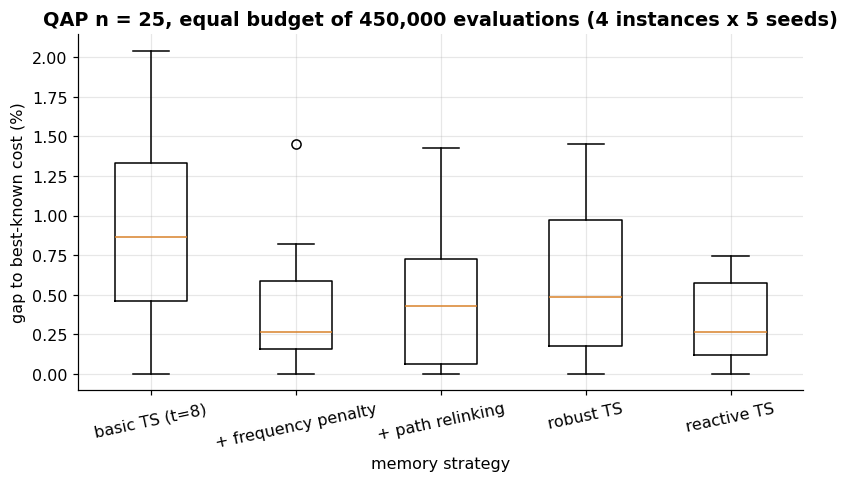

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.boxplot(list(GQ), tick_labels=list(variants), widths=0.5)
ax.set_ylabel("gap to best-known cost (%)"); ax.set_xlabel("memory strategy")
ax.set_title(f"QAP n = {n_q}, equal budget of {budget_q:,} evaluations (4 instances x 5 seeds)")
plt.setp(ax.get_xticklabels(), rotation=12)
savefig("w3_ts_memory_variants.png"); plt.show()

### What the memories do to the trajectory

Below: (left) reactive TS's prohibition period $T$ over one run, with detected repetitions marked — $T$ rises in
bursts right after repetitions and decays in quiet phases; (right) how evenly each variant spreads the search over
the $n^2$ facility–location attributes, measured by the normalised entropy of the residence-frequency matrix
$h_{i\ell}$ (1 = perfectly uniform coverage).

In [9]:
F0, D0 = insts[0]
run_r = ts_qap(F0, D0, budget_q, np.random.default_rng(3), reactive=True, record=True)
cover = {}
for name in ["basic TS (t=8)", "+ frequency penalty", "robust TS", "reactive TS"]:
    ent = []
    for sd in range(5):
        fr = ts_qap(F0, D0, budget_q, np.random.default_rng(sd), **variants[name])["freq"]
        P = fr / fr.sum()
        ent.append(-(P[P > 0] * np.log(P[P > 0])).sum() / np.log(n_q**2))
    cover[name] = ent
    print(f"{name:>20}: normalised residence entropy {np.mean(ent):.3f} ± {np.std(ent, ddof=1) / np.sqrt(5):.3f} (mean ± s.e.)")
check_true(np.mean(cover["+ frequency penalty"]) > np.mean(cover["basic TS (t=8)"]),
           "frequency penalty spreads the search over more facility-location attributes than basic TS")
print(f"reactive run: {len(run_r['rec']['rep_iters'])} repetitions detected, {len(run_r['rec']['escapes'])} escapes, "
      f"final T = {run_r['rec']['tenure'][-1]}")

      basic TS (t=8): normalised residence entropy 0.625 ± 0.013 (mean ± s.e.)


 + frequency penalty: normalised residence entropy 0.736 ± 0.012 (mean ± s.e.)


           robust TS: normalised residence entropy 0.696 ± 0.007 (mean ± s.e.)


         reactive TS: normalised residence entropy 0.769 ± 0.014 (mean ± s.e.)
[PASS] frequency penalty spreads the search over more facility-location attributes than basic TS
reactive run: 157 repetitions detected, 4 escapes, final T = 7


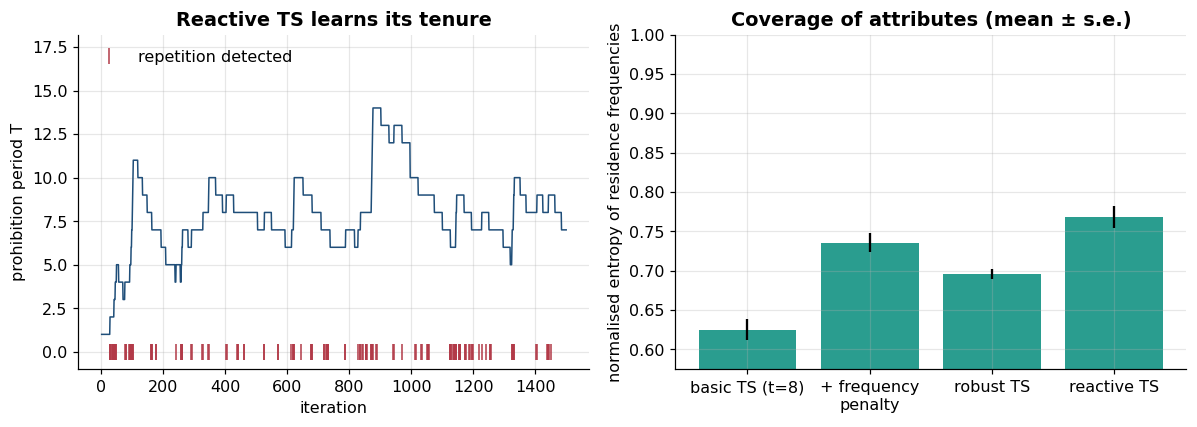

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.plot(np.arange(1, len(run_r["rec"]["tenure"]) + 1), run_r["rec"]["tenure"], color=PALETTE["blue"], lw=1)
ax.plot(run_r["rec"]["rep_iters"], np.zeros(len(run_r["rec"]["rep_iters"])), "|", color=PALETTE["red"], ms=10,
        label="repetition detected")
ax.set_xlabel("iteration"); ax.set_ylabel("prohibition period T"); ax.set_title("Reactive TS learns its tenure")
ax.set_ylim(-1, 1.3 * max(run_r["rec"]["tenure"]))
ax.legend(loc="upper left")
ax = axes[1]
names = list(cover)
ax.bar(range(len(names)), [np.mean(cover[k]) for k in names],
       yerr=[np.std(cover[k], ddof=1) / np.sqrt(5) for k in names], color=PALETTE["teal"])
ax.set_xticks(range(len(names)), [nm.replace("+ frequency penalty", "+ frequency\npenalty") for nm in names])
ax.set_ylim(min(np.mean(cover[k]) for k in names) - 0.05, 1.0)
ax.set_ylabel("normalised entropy of residence frequencies"); ax.set_title("Coverage of attributes (mean ± s.e.)")
fig.tight_layout()
savefig("w3_ts_reactive_coverage.png"); plt.show()

## 7. Strategic oscillation on the 0/1 knapsack

Many constrained problems have their best solutions **on the feasibility boundary**. A search confined to the
feasible region can only approach the boundary from one side, and exchanging items then requires detours through
much worse solutions. *Strategic oscillation* (Glover 1977; Glover & Laguna 1997, ch. 4) lets the search **cross the
boundary to a controlled depth and come back**, repeatedly, recording the best feasible solution at each crossing.

For $\max v^\top x$ s.t. $w^\top x \le C$, $x \in \lbrace 0,1 \rbrace^n$ we use flip moves and two alternating phases:

```text
phase <- ADD
repeat:
    ADD  phase: flip in the non-tabu item with the largest ratio v_i / w_i
                if load > (1 + depth) C: phase <- DROP          # crossed the boundary to the target depth
    DROP phase: flip out the non-tabu item with the smallest ratio v_i / w_i
                if load <= C: phase <- ADD                       # back on the feasible side
    a flipped item is tabu for a random tenure in [3, 10]; aspiration: any flip giving a feasible solution
    better than the best feasible one is taken first; record the best feasible solution.
```

With `depth = 0` the search overshoots by a single item before turning back. The **feasible-only** baseline uses the
same ratio rules and tabu memory but never adds an item that does not fit: when nothing fits it drops one item.
The two therefore differ *only* in whether the boundary is crossed. Each iteration evaluates all $n$ flips
($n$ evaluations).

The mechanism matters beyond knapsacks: exploring slightly infeasible configurations is how penalty-based
searches handle latency or memory budgets in neural-architecture search and model compression.

In [11]:
def knapsack_so(v, w, C, max_evals, rng, tenure=(3, 10), depth=0.03, record=False):
    """Strategic-oscillation TS for 0/1 knapsack. depth=None gives the feasible-only baseline."""
    n = len(v); ratio = v / w
    x = np.zeros(n, dtype=bool)
    val, load = 0.0, 0.0
    best, best_x = 0.0, x.copy()
    tabu_until = np.zeros(n, dtype=np.int64)
    phase, k, evals = +1, 0, 0
    rec = dict(load=[], best=[])
    while evals + n <= max_evals:
        k += 1; evals += n
        sign = np.where(x, -1.0, 1.0)
        nval, nload = val + sign * v, load + sign * w
        feas = nload <= C
        asp = feas & (nval > best)                          # aspiration by feasible objective
        free = tabu_until < k
        if phase > 0:
            cand = ~x & (free | asp)
            if depth is None:
                cand &= feas                                # feasible-only: never overshoot
            score = np.where(cand, ratio, -np.inf)
        else:
            cand = x & (free | asp)
            score = np.where(cand, -ratio, -np.inf)
        if asp.any():
            score = np.where(asp, np.inf, score)            # aspirated moves first
        if not np.any(score > -np.inf):
            evals -= n; k -= 1
            if phase > 0:
                phase = -1; continue
            break
        ties = np.flatnonzero(score == score.max())
        j = int(rng.choice(ties))
        x[j] = ~x[j]; val, load = float(nval[j]), float(nload[j])
        tabu_until[j] = k + int(rng.integers(tenure[0], tenure[1] + 1))
        if load <= C and val > best:
            best, best_x = val, x.copy()
        if phase > 0 and depth is not None and load > C * (1 + depth):
            phase = -1
        elif phase < 0 and load <= C:
            phase = +1
        if record:
            rec["load"].append(load / C); rec["best"].append(best)
    return dict(best=best, x=best_x, evals=evals, rec=rec)

### Validation against the exact dynamic programme and depth study

Pisinger-style instances with $n = 100$ in three classes (uncorrelated, weakly and strongly correlated),
8 instances each, 5 seeds, budget $20\,000$ evaluations (200 iterations); `knapsack_dp` gives the exact optimum.
Checks: every reported solution is feasible, its value is recomputed from scratch and never exceeds the optimum;
oscillation must reach the DP optimum on at least some runs of every class.

In [12]:
t0 = time.time()
depths = [0.0, 0.01, 0.03, 0.1, None]
dnames = ["depth 0", "depth 1%", "depth 3%", "depth 10%", "feasible-only"]
classes = ["uncorrelated", "weak", "strong"]
HITS = np.zeros((len(classes), len(depths)), dtype=int)
GAPS = np.zeros((len(classes), len(depths), 40))
all_ok = True
for c, corr in enumerate(classes):
    for inst in range(8):
        v, w, C = random_knapsack(100, np.random.default_rng(500 + inst), correlation=corr)
        opt, _ = knapsack_dp(v, w, C)
        for sd in range(5):
            for d_, dep in enumerate(depths):
                res = knapsack_so(v, w, C, 20_000, np.random.default_rng(sd), depth=dep)
                xb = res["x"]
                all_ok &= (w[xb].sum() <= C) and abs(v[xb].sum() - res["best"]) < 1e-9 and res["best"] <= opt + 1e-9
                GAPS[c, d_, inst * 5 + sd] = 100 * (opt - res["best"]) / opt
                HITS[c, d_] += opt - res["best"] < 1e-9
check_true(all_ok, "all 600 reported solutions are feasible, values recomputed exactly, never above the DP optimum")
print(f"{'':>14}" + "".join(f"{d:>22}" for d in dnames))
for c, corr in enumerate(classes):
    print(f"{corr:>14}" + "".join(f"{HITS[c, d]:>5d}/40 {GAPS[c, d].mean():6.3f}±{GAPS[c, d].std(ddof=1) / np.sqrt(40):.3f}%"
                                   for d in range(len(depths))))
print("(cells: exact-optimum hits, mean gap ± s.e.)")
print(f"({time.time() - t0:.1f} s)")
check_true(np.all(HITS[:, 0] > 0), "oscillation (depth 0) reaches the DP optimum in every instance class")
check_true(np.all(GAPS[:2, 0].mean(1) < GAPS[:2, -1].mean(1)),
           "on uncorrelated and weakly correlated instances crossing the boundary beats feasible-only")

[PASS] all 600 reported solutions are feasible, values recomputed exactly, never above the DP optimum
                             depth 0              depth 1%              depth 3%             depth 10%         feasible-only
  uncorrelated   21/40  0.039±0.008%   21/40  0.044±0.009%   17/40  0.057±0.010%   12/40  0.091±0.012%    0/40  0.631±0.063%
          weak   24/40  0.021±0.004%   19/40  0.024±0.004%   23/40  0.020±0.004%   10/40  0.062±0.009%    0/40  2.580±0.350%
        strong   40/40  0.000±0.000%   38/40  0.002±0.001%   39/40  0.006±0.006%   36/40  0.009±0.006%   37/40  0.015±0.010%
(cells: exact-optimum hits, mean gap ± s.e.)
(22.2 s)
[PASS] oscillation (depth 0) reaches the DP optimum in every instance class
[PASS] on uncorrelated and weakly correlated instances crossing the boundary beats feasible-only


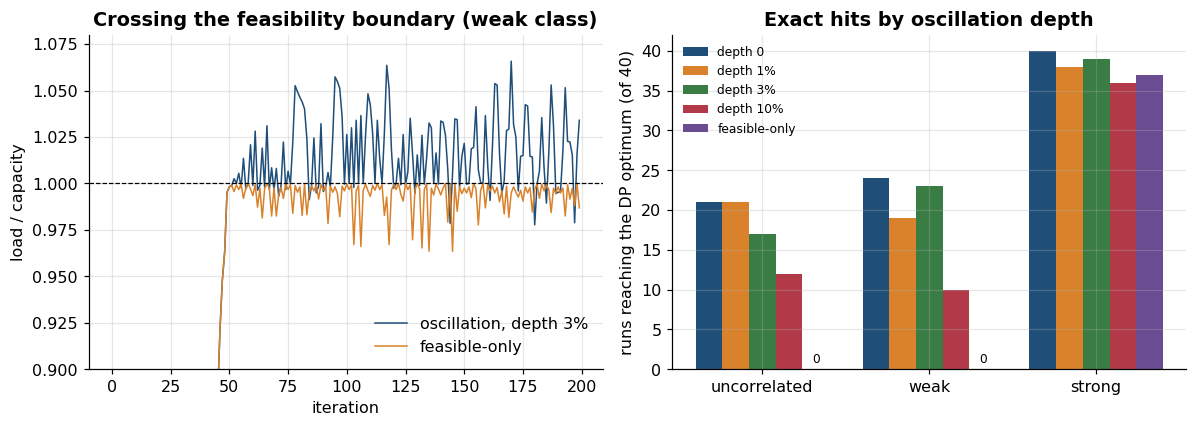

In [13]:
v, w, C = random_knapsack(100, np.random.default_rng(501), correlation="weak")
opt, _ = knapsack_dp(v, w, C)
ro = knapsack_so(v, w, C, 20_000, np.random.default_rng(0), depth=0.03, record=True)
rf = knapsack_so(v, w, C, 20_000, np.random.default_rng(0), depth=None, record=True)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.plot(ro["rec"]["load"], color=PALETTE["blue"], lw=1, label="oscillation, depth 3%")
ax.plot(rf["rec"]["load"], color=PALETTE["orange"], lw=1, label="feasible-only")
ax.axhline(1.0, color="k", ls="--", lw=0.8)
ax.set_ylim(0.9, 1.08)
ax.set_xlabel("iteration"); ax.set_ylabel("load / capacity"); ax.set_title("Crossing the feasibility boundary (weak class)")
ax.legend(loc="lower right")
ax = axes[1]
xx = np.arange(len(classes)); wd = 0.16
for d_ in range(len(depths)):
    bars = ax.bar(xx + (d_ - 2) * wd, HITS[:, d_], wd, label=dnames[d_])
    for bx, hv in zip(xx + (d_ - 2) * wd, HITS[:, d_]):
        if hv == 0:
            ax.text(bx, 0.5, "0", ha="center", va="bottom", fontsize=8)     # zero-height bars stay visible
ax.set_xticks(xx, classes); ax.set_ylabel("runs reaching the DP optimum (of 40)")
ax.set_title("Exact hits by oscillation depth"); ax.legend(fontsize=8)
fig.tight_layout()
savefig("w3_strategic_oscillation.png"); plt.show()

## Key takeaways

- The tabu list is *recency* memory; **long-term frequency** memory drives diversification (penalising
  over-used attributes), and **elite / quality** memory drives intensification (restarts, path relinking).
- **Robust TS** replaces a hand-tuned fixed tenure by a randomised one around $n$ (plus long-term aspiration);
  **reactive TS** *learns* the tenure online from repetitions detected by $O(1)$ Zobrist hashing — a self-adaptive
  parameter-control mechanism of the same family as the 1/5-th rule and CMA-ES step-size control (Week 6).
- **Path relinking** explores the space *between* elite solutions, with at most $n-1$ greedy steps for permutations.
- **Strategic oscillation** exploits the fact that optima of constrained problems typically lie on the feasibility
  boundary: crossing it to a controlled depth and coming back reaches the knapsack DP optimum far more often than an
  otherwise identical feasible-only search on uncorrelated and weakly correlated instances (equal budget).
- The same memory ideas transfer to AI search problems: frequency penalties for diversity in hyperparameter or
  neural-architecture search, elite relinking between good configurations, and oscillation around constraints such
  as latency or memory budgets in model compression.

## Exercises

1. ★ Show that path relinking between two permutations that differ in $m$ positions takes at most $m - 1$ steps,
   and that this bound is tight exactly when the permutation $x^G \circ (x^I)^{-1}$ restricted to those positions is
   a single cycle.
2. ★ Prove the birthday bound: with $m$ stored 64-bit Zobrist hashes (independent uniform keys), the probability
   that two distinct solutions share a hash is at most $m(m-1)/2^{65}$.
3. ★★ Replace the residence frequency by a *transition* frequency (how often facility $i$ was moved) and compare
   diversification strength and final quality at equal budget.
4. ★★ Penalty-based oscillation: with $g_\lambda(x) = v^\top x - \lambda \max(0, w^\top x - C)$ and integer
   weights, prove that for fixed $\lambda \gt \max_i v_i$ every local maximum of $g_\lambda$ under single flips is
   feasible, and show by a two-item example that $\lambda \gt \max_i v_i / w_i$ is not sufficient. Implement an
   adaptive-$\lambda$ variant and compare it with the phase-based oscillation above.
5. ★★ Implement *mixed* path relinking (walk alternately from both ends) and *truncated* relinking (stop after
   $m/2$ steps); compare with the greedy version at equal budget.
6. ★★★ Build a reactive TS for feature selection (bit-flip moves, objective = validation error of a least-squares
   model plus a size penalty) with Zobrist hashing on bit vectors. Measure how $T$ evolves and compare with a
   fixed-tenure TS over 20 seeds using a Wilcoxon signed-rank test.